In [22]:
# project 1st file 기본 전처리 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import preprocessing
importlib.reload(preprocessing)

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 

In [24]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


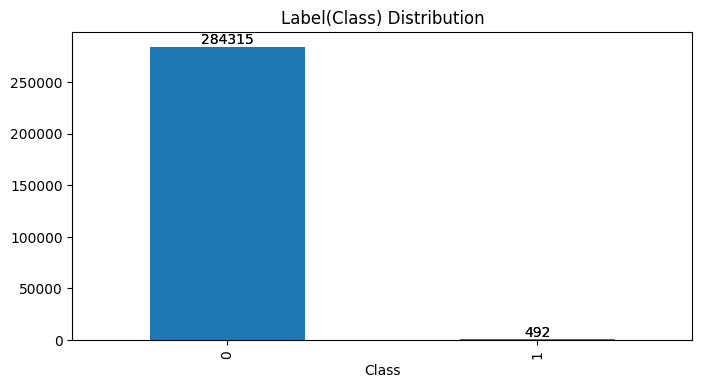

In [25]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=True)


In [ ]:
# 2. Data전처리
# Amount와 Time 스케일링 (V1-V28은 이미 PCA 처리됨)
df_scaled = pp.robustScaler(df)
# robutScaler : 이상치가 많은 데이터에 좋음

✅ 'Amount' 스케일링 완료 → 'Amount_scaled'
✅ 'Time' 스케일링 완료 → 'Time_scaled'

🗑️  원본 컬럼 제거: ['Amount', 'Time']

✅ 스케일링 완료: 2개 컬럼
   최종 shape: (284807, 31)


In [ ]:
# df_sacled.head()
## 데이터 
X_features, y_target = pp.split_features_target(df_scaled)
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [28]:
X_over, y_over = ds.oversampling_smote(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_over)}')
print(y_over.value_counts())

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
Before : 227845, After: 454902
Class
0    227451
1    227451
Name: count, dtype: int64


In [29]:
X_under, y_under = ds.undersampling_RUS(X_train, y_train)
print(f'Before : {len(y_train)}, After: {len(y_under)}')
print(y_under.value_counts())

✅ 랜덤 언더샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 788 (Class 0: 394, Class 1: 394)
   제거된 샘플: 227057개
Before : 227845, After: 788
Class
0    394
1    394
Name: count, dtype: int64


In [30]:
X_combined, y_combined = ds.combined_sampling(X_train, y_train)

✅ SMOTETomek 혼합 샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
   최종 변화: +227057개


In [31]:
## 모덱 학습
from sklearn.ensemble import RandomForestClassifier
# scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42
model_name = 'RandomForest_00samples_2025_11_26'
rf_best_param = {
    "random_state": 23,
    "n_estimators": 390,
    "max_depth": 25,
    "class_weight": {0: 1, 1: 2},
    "min_samples_leaf": 1,
    "min_samples_split": 7,
    "n_jobs": -1
}
rf_clf = RandomForestClassifier(**rf_best_param)

uu.get_model_train_eval(rf_clf,model_name, X_train, X_test, y_train, y_test)

✓ 모델 저장 완료: ../models\RandomForest_00samples_2025_11_26.pkl
  파일 크기: 7.92 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9647, 정확도: 0.9996, 정밀도: 0.9310, 재현율: 0.8265, F1: 0.8757
오차행렬:
[[56858     6]
 [   17    81]]
실행 시간: 115.5803689956665
